In [7]:
%matplotlib widget

import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np

In [2]:
with open("logs/runtime_results.pkl", "rb") as f:
    results_by_nodes_clean = pickle.load(f)

In [3]:
offsets_by_depth_rec = defaultdict(list)
offsets_by_depth_comb = defaultdict(list)

for result in results_by_nodes_clean:
    _, (floor_7r, ceil_7r), value_7r = result[(7, "recursive")]
    _, (floor_7c, ceil_7c), value_7c = result[(7, "combo")]
    # target = (floor_7r + ceil_7r + ceil_7r + floor_7c) / 4
    target = (value_7c + value_7r) / 2

    for (depth, algo), (runtime, (floor, ceil), value) in result.items():
        mid = value # (floor + ceil) / 2
        offset = mid - target
        if algo == "recursive":
            offsets_by_depth_rec[depth].append(offset)
        else:
            offsets_by_depth_comb[depth].append(offset)

In [4]:
result[(7, "recursive")]

(295.6471474170685,
 (np.float64(10.484348483210308), np.float64(10.491354941342568)),
 np.float64(10.484440755665684))

2
3
4
5
6


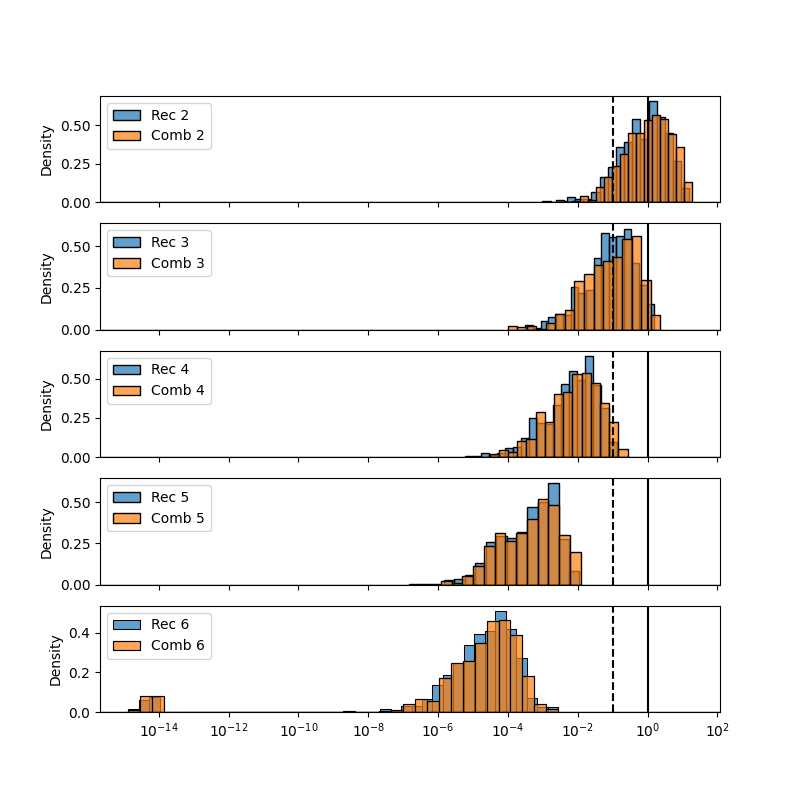

In [16]:
f, axes = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
axes = axes.ravel()

for d, ax in zip(range(2, 7), axes):
    print(d)
    # ax.hist(offsets_by_depth_rec[d])
    sns.histplot(np.abs(offsets_by_depth_rec[d]), ax=ax, label=f"Rec {d}", alpha=0.7, stat="density", log_scale=True)
    sns.histplot(np.abs(offsets_by_depth_comb[d]), ax=ax, label=f"Comb {d}", alpha=0.7, stat="density", log_scale=True)
    ax.legend()
    ax.axvline(-0.1, color="k", ls="--")
    ax.axvline(0.1, color="k", ls="--")
    ax.axvline(-1, color="k")
    ax.axvline(1, color="k")
    ax.axhline(0, color="k", lw=1)
# plt.tight_layout()
plt.show()

In [13]:
print(np.mean(np.abs(offsets_by_depth_rec[3]) < 0.2), np.mean(np.abs(offsets_by_depth_comb[3]) < 0.2))
print(np.mean(np.abs(offsets_by_depth_rec[4]) < 0.1), np.mean(np.abs(offsets_by_depth_comb[4]) < 0.1))

0.6818181818181818 0.6145454545454545
0.990909090909091 0.96


In [6]:
import numpy as np


for d in range(2, 8):
    print(d)
    print(np.mean(offsets_by_depth_rec[d]))
    print(np.mean(offsets_by_depth_comb[d]))
    print()

2
0.35180854843382703
0.5574717581076205

3
-0.013740094187129645
0.010201176548091674

4
-0.002855891560422466
0.0008651277019901844

5
-6.927963210485797e-05
-5.808985004469933e-06

6
-7.987279720912702e-06
-1.198487037048042e-05

7
6.135828076075429e-08
-6.1358280949959e-08

